In [1]:
import numpy as np
import matplotlib.pyplot as plt
import unitaria as ut

np.set_printoptions(precision=3, suppress=True, threshold=100)

# Block Encoding the 1D Poisson Problem

This notebook provides an example code for encoding and solving a prototypical boundary value problem involving the Laplace operator using `unitaria`.

## 1. Problem Setup and Constants

On the unit interval $D = [0, 1]$ we consider the Poisson equation with homogeneous Dirichlet boundary condition,
\begin{align*}
-\Delta u &= f && \text{in }D \\
u &= 0 && \text{on }\partial D
\end{align*}
Given a right-hand side $f \in L^2(D)$, we seek the unique weak $u \in H^1_0(D)$, which satisfies
$$
a(u, v):= (\nabla u, \nabla v)_{L^2} = (v, f)_{L^2} \qquad\forall v \in H^1_0(D).
$$

## 2. Discretizing the Poisson problem

To discretize the variational problem we choose a finite-dimensional subspace
of $H^1_0(D)$ consisting of piecewise linear functions on a uniform subdivision
of $D$ into $2^N$ subintervals of width $h = 2^{-N}$,
$$
    D = [x_0, x_1] \cup \cdots \cup [x_{2^N - 1}, x_{2^N}],
$$
with vertices $x_j := jh$, $j = 0, \ldots, 2^N$. This corresponds to
refining the unit interval $N$ times uniformly by bisection. For the examples
below we choose the refinement level

In [2]:
N = 3

We now consider the basis of *hat functions* $\Lambda_1, \dots, \Lambda_{2^N-1}$
(the simplest example of *finite element* basis functions) associated to
the interior vertices $x_1, \ldots, x_{2^N - 1}$ (the boundary vertices $x_0$
and $x_{2^N}$ are excluded by the homogeneous Dirichlet condition), which are
continuous, piecewise linear on the above intervals, and satisfy
$$
\Lambda_j(x_k) = \begin{cases} 1 & j = k, \\ 0 & j \neq k. \end{cases}
$$
The discrete stiffness matrix $A \in \mathbb{R}^{(2^N-1)\times(2^N-1)}$ (the
matrix representation of $a(\cdot,\cdot)$ in the hat function basis) is given by$$A_{jk} = a(\Lambda_j, \Lambda_k) = \begin{cases}
2^{N + 1} & \text{if } j = k \text{  (diagonal)}, \\
-2^N & \text{if } j = k-1 \text{ or } j = k+1 \text{  (super-/subdiagonal)}.
\end{cases}
$$

## 3. Block encoding the stiffness matrix

To perform computations involving the stiffness matrix on a quantum computer, we
need to construct a *block encoding* of $A$, i.e. a unitary matrix that
embeds $A$ in its upper-left block (see [Quantum singular value transformation and beyond: exponential improvements for quantum matrix arithmetics](https://arxiv.org/abs/1806.01838) for details). This is where
`unitaria` comes in.

To efficiently block encode $A$, we exploit its tridiagonal structure and
decompose it into simpler components,
$$
    A = 2^N
    \begin{bmatrix}
        2 & -1 & & \\
        -1 & \ddots & \ddots & \\
        & \ddots & \ddots & -1 \\
        & & -1 & 2
    \end{bmatrix}
    = 2^N \bigl(2I - X - X^T\bigr),
$$
where $I = I_{2^N - 1}$ is the identity and $X$ is the subdiagonal shift matrix
$$    
    X = \begin{bmatrix}
        0 & & \\
        1 & \ddots & \\
        & \ddots & 0
    \end{bmatrix}.
$$
Each of these three matrices $I$, $X$, and $X^T$ admits an efficient
block encoding, which can then be combined linearly to yield a block encoding
of $A$.

### The matrix $I$
The identity is straightforward to block encode. `unitaria` provides a
built-in routine for this.

In [3]:
Id = ut.Identity(dim=2**N - 1)

The variable `Id` contains the block encoding of the identity: the encoded
operation together with the quantum circuit, normalisation factor, and subspace
information required to use it. The method `.circuit()` returns the circuit,
which we can visualise by calling `.draw()` on it.

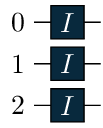

In [4]:
Id.circuit().draw()

Encoding the identity simply means doing nothing, so the circuit applies the
identity gate to each qubit. The circuit acts on $m = 3$ qubits, since the
state space dimension $2^m = 8$ must be at least as large as the matrix
dimension $2^N - 1 = 7$. The circuit therefore encodes the full $8 \times 8$
identity. The attributes `Id.subspace_in` and `Id.subspace_out` specify that
only the first 7 rows and columns are used. The normalisation factor is 1,
as expected for a matrix with spectral norm 1.

In [5]:
print(Id.subspace_in.enumerate_basis())
print(Id.subspace_out.enumerate_basis())
Id.normalization

[0 1 2 3 4 5 6]
[0 1 2 3 4 5 6]


1

We can also print the encoded matrix directly.

In [6]:
print(Id.toarray())

[[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]


### The matrix $X$

The matrix $X$ has $1$s on its first subdiagonal, mapping the $j$-th basis
vector to the $(j+1)$-th basis vector. This is the binary increment operation
$|x\rangle \mapsto |x+1\rangle$.

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]]


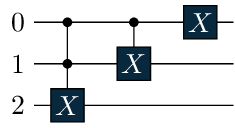

In [7]:
# Basic shift operator
X_periodic = ut.Increment(bits=N)
print(X_periodic.toarray())
X_periodic.circuit().draw()

Note that this is not quite the matrix we wanted. The block encoding
`X_periodic` implements the increment **modulo $2^N$**, so incrementing
$2^N - 1$ wraps around to $0$, placing a $1$ in the upper-right corner.
This would give a block encoding of the **periodic** version of the stiffness
matrix, rather than the one with Dirichlet boundary conditions.

[[16.+0.j -8.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -8.+0.j]
 [-8.+0.j 16.+0.j -8.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -8.+0.j 16.+0.j -8.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -8.+0.j 16.+0.j -8.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -8.+0.j 16.+0.j -8.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j -8.+0.j 16.+0.j -8.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -8.+0.j 16.+0.j -8.+0.j]
 [-8.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -8.+0.j 16.+0.j]]


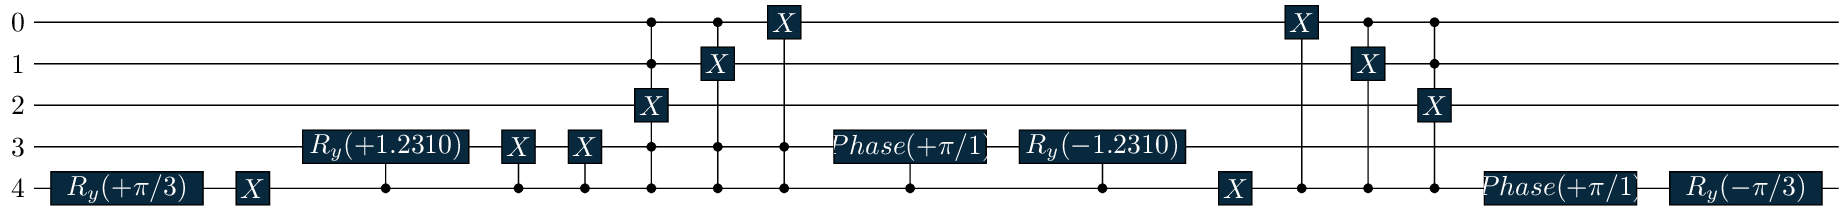

In [8]:
A_periodic = 2**N * (2 * ut.Identity(dim=2**N) - X_periodic - X_periodic.adjoint())
print(A_periodic.toarray())
A_periodic.circuit().draw()

## Boundary Conditions

The increment operator is cyclic: it wraps around from $2^N - 1$ back to $0$,
which places unwanted $-1$ entries in the corners of the stiffness matrix and
is incompatible with Dirichlet boundary conditions. To remove this wrap-around,
we restrict the operator to a subspace that excludes the boundary states. This
is done internally via multiplication with a projection matrix. Let us first inspect the total space of the
`X_periodic` block encoding.

In [9]:
A = A_periodic[:-1, :-1]

## Constructing the right-hand side

To solve the system $Au = b$, we need to encode the vector $b$, which is determined by the forcing term $f$. Choosing $f \equiv 1$ gives $b = 2^{-N}[1, \ldots, 1]^T$. The function `ConstantVector` in `unitaria` encodes this vector, though state preparation is not efficient in general.

In [10]:
b = ut.ConstantVector(2 ** (-N) * np.ones(2**N - 1))
print(f"depth = {b.circuit().depth()}")

depth = 11


For this specific choice of $f$, however, an efficient encoding exists. Up to the same projection as before, $b$ is a tensor product of $N$ two-dimensional vectors, which can be constructed efficiently using `ut.Tensor` (or the `&`
operator).

In [11]:
vec2d = ut.ConstantVector(1 / 2 * np.ones(2))
b = (vec2d & vec2d & vec2d)[:-1]

print(f"depth = {b.circuit().depth()}")
b.toarray()

depth = 2


array([0.125+0.j, 0.125+0.j, 0.125+0.j, 0.125+0.j, 0.125+0.j, 0.125+0.j,
       0.125+0.j])

## Computing the inverse

A quantum linear system solver requires an upper bound on the condition number
of $A$. Here we compute it numerically.

In [12]:
condition = np.linalg.cond(A.toarray(), p=2)
condition

np.float64(25.274142369088185)

The condition number grows large as $N$ increases — as seen above for $N = 3$,
it is already $25$. A systematic treatment via preconditioning is given in
[Quantum realization of the Finite Element Method](https://doi.org/10.1090/mcom/4137), but this is outside the scope of this tutorial.

To invert `A` we apply the `Pseudoinverse` function. This uses the QCheb solver from [Constrained Optimal Polynomials for Quantum Linear System Solvers
Matthias](https://arxiv.org/abs/2604.20513).

In [13]:
A_inv = ut.Pseudoinverse(A, condition=condition, tolerance=0.05)

Internally, `Pseudoinverse` is implemented via `ut.QSVT`. In `unitaria`,
operations built from other operations, such as `Pseudoinverse`, are
subclasses of `ProxyNode`, which allows us to inspect their underlying
definition.

In [14]:
print(type(A_inv.get_definition()))
print(A_inv.get_definition().coefficients.angles)
print(len(A_inv.get_definition().coefficients.angles))

<class 'unitaria.nodes.qsvt.qsvt.QSVT'>
[-2.359 -1.567 -1.575 -1.566 -1.577 -1.564 -1.578 -1.562 -1.581 -1.56
 -1.583 -1.557 -1.586 -1.555 -1.588 -1.552 -1.592 -1.548 -1.595 -1.545
 -1.598 -1.542 -1.602 -1.538 -1.605 -1.535 -1.608 -1.532 -1.611 -1.529
 -1.614 -1.527 -1.616 -1.525 -1.617 -1.524 -1.618 -1.524 -1.617 -1.525
 -1.616 -1.526 -1.614 -1.528 -1.528 -1.614 -1.526 -1.616 -1.525 -1.617
 -1.524 -1.618 -1.524 -1.617 -1.525 -1.616 -1.527 -1.614 -1.529 -1.611
 -1.532 -1.608 -1.535 -1.605 -1.538 -1.602 -1.542 -1.598 -1.545 -1.595
 -1.548 -1.592 -1.552 -1.588 -1.555 -1.586 -1.557 -1.583 -1.56  -1.581
 -1.562 -1.578 -1.564 -1.577 -1.566 -1.575 -1.567 -2.359]
88


The solver works by approximating the function $1/x$ by a polynomial, which is
then applied to the singular values of $\tilde{A}$ via QSVT.

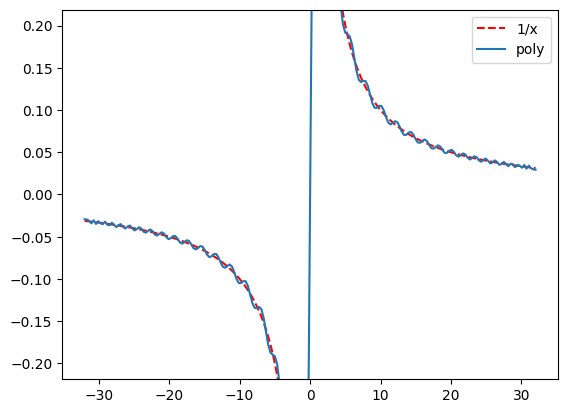

In [15]:
poly = A_inv.get_definition().polynomial
xs = np.linspace(-A.normalization, A.normalization, 200)
plt.plot(xs[xs > 0], 1 / xs[xs > 0], "r--", label="1/x")
plt.plot(xs[xs < 0], 1 / xs[xs < 0], "r--")
plt.plot(xs, poly(xs), label="poly")
plt.legend()
_ = plt.ylim([-7 / A.normalization, 7 / A.normalization])

The plot shows the polynomial approximation to $1/x$ on the spectral range of
$\tilde{A}$. We can now apply the inverse to the right-hand side. As in NumPy,
matrix-vector and matrix-matrix products use the `@` operator.

In [16]:
solution = A_inv @ b

## Verification and simulation

We verify the result in two ways: by converting the block encoding to an explicit matrix via `.toarray()`, and by running the internal quantum simulator via `.simulate()`. Both checks, along with a comparison to a reference value,
are performed automatically by `ut.verify`.

In [17]:
dim = 2**N - 1
A_reference = 2**N * (2 * np.eye(dim) - np.eye(dim, k=-1) - np.eye(dim, k=1))
reference = np.linalg.solve(A_reference, 2 ** (-N) * np.ones(dim))
ut.verify(A, A_reference)
ut.verify(solution, reference, atol=0.15)

In practice, we are typically interested in a scalar quantity derived from the solution, such as the $L^2$ norm of $u$. This is approximated by $2^{-N/2}$ times the Euclidean norm of the solution vector.

In [18]:
measured_qoi = solution.simulate_norm() * 2 ** (-N / 2)
print(f"Measured quantity of interest: {measured_qoi}")
print(f"Classically computed quantity of interest: {solution.compute_norm() * 2 ** (-N / 2)}")

Measured quantity of interest: 0.08296009451523294
Classically computed quantity of interest: 0.08296009451513568


We compare this against a reference value computed on a finer grid.

In [19]:
N_reference = 12
dim = 2**N_reference - 1
reference = np.linalg.solve(
    2**N_reference * (2 * np.eye(dim) - np.eye(dim, k=-1) - np.eye(dim, k=1)), 2 ** (-N_reference) * np.ones(dim)
)
reference_qoi = np.linalg.norm(reference) * 2 ** (-N_reference / 2)
print(f"Reference quantity of interest: {reference_qoi}")
print(f"Error: {abs(measured_qoi - reference_qoi):.2e}")

Reference quantity of interest: 0.09128709291789493
Error: 8.33e-03


The error is within the specified tolerance.

## Under the hood

To illustrate the complexity of the block encodings constructed automatically by `unitaria`, we can inspect the full computational graph by calling `.draw(verbose=True)`, which expands all `ProxyNode` definitions. This reveals that every operation ultimately reduces to a small set of primitive node types.

In [20]:
A_inv.tree(verbose=True)

╭─ Pseudoinverse{'condition': np.float64(25.274142369088185), 'tolerance': 0.05, 'guaranteed': False} ────────────╮
│ QSVT{'polynomial': Chebyshev([ 0.   ,  0.062,  0.   , -0.06 ,  0.   ,  0.058,  0.   , -0.056,                   │
│         0.   ,  0.054,  0.   , -0.052,  0.   ,  0.051,  0.   , -0.049,                                          │
│         0.   ,  0.047,  0.   , -0.045,  0.   ,  0.043,  0.   , -0.042,                                          │
│         0.   ,  0.04 ,  0.   , -0.038,  0.   ,  0.037,  0.   , -0.035,                                          │
│         0.   ,  0.033,  0.   , -0.032,  0.   ,  0.03 ,  0.   , -0.029,                                          │
│         0.   ,  0.027,  0.   , -0.026,  0.   ,  0.024,  0.   , -0.023,                                          │
│         0.   ,  0.022,  0.   , -0.02 ,  0.   ,  0.019,  0.   , -0.018,                                          │
│         0.   ,  0.017,  0.   , -0.016,  0.   ,  0.015,  0.   , -0.014,                                          │
│         0.   ,  0.012,  0.   , -0.012,  0.   ,  0.011,  0.   , -0.01 ,                                          │
│         0.   ,  0.009,  0.   , -0.008,  0.   ,  0.007,  0.   , -0.007,                                          │
│         0.   ,  0.006,  0.   , -0.005,  0.   ,  0.005,  0.   , -0.004], domain=[-32.,  32.], window=[-1.,  1.], │
│ symbol='x'), 'normalization': np.float64(0.7488139573322291)}                                                   │
│ └── Adjoint                                                                                                     │
│     └── child 0                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
└── ╭─ Index{'index_in': slice(0, 7, 1), 'index_out': slice(0, 7, 1)} ────────────────────────────────────────────╮
    │ ╭─ Mul ───────────────────────────────────────────────────────────────────────────────────────────────────╮ │
    │ │ UnsafeMul                                                                                               │ │
    │ │ ├── UnsafeMul                                                                                           │ │
    │ │ │   ├── Tensor                                                                                          │ │
    │ │ │   │   ├── Identity{'subspace': Subspace("0")}                                                         │ │
    │ │ │   │   └── UnsafeMul                                                                                   │ │
    │ │ │   │       ├── child 0                                                                                 │ │
    │ │ │   │       └── Adjoint                                                                                 │ │
    │ │ │   │           └── Identity{'subspace': Subspace("000###")}                                            │ │
    │ │ │   └── SubspaceCircuit                                                                                 │ │
    │ │ └── Tensor                                                                                              │ │
    │ │     ├── Identity{'subspace': Subspace("0")}                                                             │ │
    │ │     └── UnsafeMul                                                                                       │ │
    │ │         ├── Identity{'subspace': Subspace("00###")}                                                     │ │
    │ │         └── child 1                                                                                     │ │
    │ ╰─────────────────────────────────────────────────────────────────────────────────────────────────────────╯ │
    │ ├── ╭─ Mul ───────────────────────────────────────────────────────────────────────────────────────────────╮ │
    │ │   │ UnsafeMul                                   